In [59]:
#Import libraries and dependencies

import sys
import os
import glob
import csbdeep
import tensorflow as tf
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from stardist.models import StarDist2D

print("Python:", sys.executable)

Python: /home/rootwsl2/miniconda3/envs/stardist/bin/python


In [60]:
#Import stardist model

model = StarDist2D(
    None,
    name="Model",
    basedir="/mnt/c/Users/hbruce/Desktop/stardist_cIN_model" #input path to the model here
)
print("Model loaded successfully")

Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.586955, nms_thresh=0.3.
Model loaded successfully


In [61]:
#Set up input/output folders for batch analysis and configure threshold for measurements
#If the tif is multiple channels, you can calso define which channel you want the tracking to be done on


INPUT_DIR = "/mnt/c/Users/hbruce/Desktop/stardist_cIN_model/stardist_input" #Change accordingly:you should have you .tif videos here
OUTPUT_DIR = "/mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output" #Change accordingly 
STATS_OUTPUT_DIR = "/mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/stats" #Change accordingly

os.makedirs(OUTPUT_DIR, exist_ok=True) #automatically creates an output folder if it doesn't already exist
os.makedirs(STATS_OUTPUT_DIR, exist_ok=True) #automatically creates stats output folder if it doesn't already exist

input_paths = sorted(glob.glob(os.path.join(INPUT_DIR, "*.tif"))) #tells the script that every .tif file is to be read and used

# Tracking / analysis parameters applied to every movie
#For mouse use 35, for human 65 --> based on Antonela's data analysis
MAX_DISPLACEMENT_UM = 35.0 

MAX_FRAME_GAP = 1 #allow an onject to be missed for this many consecutive frames

#Nucleokinesis analysis
#Mouse = 5.0, human = 10.0
NUCLEOKINESIS_THRESHOLD_UM = 5.0

#Pause threshold
PAUSE_THRESHOLD_UM = 0.5

#Minimum tracking durationop
MIN_TRACK_DURATION_HOURS = 5.0

#Polarity measurements
REVERSAL_ANGLE_THRESHOLD_DEG = 135.0

#Tiling:breaks the data up into smaller chunks for running the segmentation model
#For data collected as 1024 x 1024 tiling of (2,2) works, for larger data you can increase the n tiles e.g. (4,4)
N_TILES = (2, 2) 

CHANNEL_TO_TRACK = 0  # index of the channel to run StarDist/tracking on (0-based)

print(f"Found {len(input_paths)} movie(s) to process:")
for p in input_paths:
    print(" ", os.path.basename(p))

Found 8 movie(s) to process:
  HB_E13_MGE_Sex_02032026_Embryo1_Female.tif
  HB_E13_MGE_Sex_02032026_Embryo2_Male.tif
  HB_E13_MGE_Sex_02032026_Embryo3_Male.tif
  HB_E13_MGE_Sex_02032026_Embryo4_Female.tif
  HB_E13_MGE_Sex_02032026_Embryo5_Female.tif
  HB_E13_MGE_Sex_02032026_Embryo6_Male.tif
  HB_E13_MGE_Sex_02032026_Embryo7_Male.tif
  HB_E13_MGE_Sex_02032026_Embryo8_Female.tif


In [62]:
#Function to read and calibrate tiff metadata (multichannel-aware)

def read_calibrated_tiff(input_path, channel_to_track=0):
    """
    Read a timelapse TIFF and pull out its ImageJ calibration.
    If the file is a multichannel hyperstack, only `channel_to_track`
    is returned as calib["movie"] (T, Y, X) - everything downstream
    (segmentation, tracking, metrics) is unaffected by extra channels.
    The full multichannel array is kept as calib["full_movie"] in case
    you want to pull intensity from other channels later.
    """
    with tifffile.TiffFile(input_path) as tif:
        series = tif.series[0]
        full_movie = series.asarray()
        axes = series.axes  # e.g. "TYX", "TCYX", "TZCYX"
        imagej_metadata = dict(tif.imagej_metadata) if tif.imagej_metadata else {}
        page0 = tif.pages[0]

        x_resolution = page0.tags["XResolution"].value if "XResolution" in page0.tags else None
        y_resolution = page0.tags["YResolution"].value if "YResolution" in page0.tags else None
        resolution_unit = page0.tags["ResolutionUnit"].value if "ResolutionUnit" in page0.tags else None

    unit = imagej_metadata.get("unit")
    spacing = imagej_metadata.get("spacing")
    frame_interval = imagej_metadata.get("finterval")
    labels = imagej_metadata.get("Labels")

    if unit != "micron" or x_resolution is None or y_resolution is None:
        raise ValueError(
            f"{os.path.basename(input_path)}: missing or unsupported spatial "
            f"calibration (unit={unit})"
        )

    if "C" in axes:
        c_index = axes.index("C")
        n_channels = full_movie.shape[c_index]
        if not (0 <= channel_to_track < n_channels):
            raise ValueError(
                f"{os.path.basename(input_path)}: channel_to_track={channel_to_track} "
                f"out of range for {n_channels} channels"
            )
        movie = np.take(full_movie, indices=channel_to_track, axis=c_index)
        if "Z" in axes:
            raise NotImplementedError(
                f"{os.path.basename(input_path)}: has a Z axis ({axes}) - this pipeline "
                "assumes single-plane timelapses. Add a Z-selection or max-projection "
                "step here if your data has multiple Z planes."
            )
    else:
        n_channels = 1
        movie = full_movie

    x_res = x_resolution[0] / x_resolution[1]
    y_res = y_resolution[0] / y_resolution[1]
    pixels_per_micron = (x_res + y_res) / 2.0

    return {
        "movie": movie,                 # (T, Y, X) - tracked channel only, unchanged shape for downstream code
        "full_movie": full_movie,       # original array, all channels, in case needed later
        "axes": axes,
        "n_channels": n_channels,
        "channel_to_track": channel_to_track,
        "imagej_metadata": imagej_metadata,
        "x_resolution": x_resolution,
        "y_resolution": y_resolution,
        "resolution_unit": resolution_unit,
        "unit": unit,
        "spacing": spacing,
        "frame_interval": frame_interval,
        "labels": labels,
        "pixels_per_micron": pixels_per_micron,
    }

In [63]:
#define function to run stardist segmentation on a single timelapse series

def run_stardist_on_movie(movie, model, n_tiles=(2, 2)):
    all_labels = []
    all_points = []

    for t in range(movie.shape[0]):
        frame = movie[t].astype(np.float32)
        labels, details = model.predict_instances(frame, n_tiles=n_tiles)

        all_labels.append(labels)
        all_points.append(details["points"])

        print(f"    frame {t + 1}/{movie.shape[0]}: {len(details['points'])} objects")

    return all_labels, all_points

In [64]:
#Define function to save segmentation stacks with original metadata from .tif file

def save_segmentation(all_labels, calib, input_path, output_dir):
    segmentation = np.stack(all_labels).astype(np.uint16)

    output_metadata = dict(calib["imagej_metadata"])
    output_metadata["images"] = segmentation.shape[0]
    output_metadata["frames"] = segmentation.shape[0]
    if calib["spacing"] is not None:
        output_metadata["spacing"] = calib["spacing"]
    if calib["unit"] is not None:
        output_metadata["unit"] = calib["unit"]
    if calib["frame_interval"] is not None:
        output_metadata["finterval"] = calib["frame_interval"]
    if calib["labels"] is not None:
        output_metadata["Labels"] = calib["labels"]
    if "Properties" in calib["imagej_metadata"]:
        output_metadata["Properties"] = calib["imagej_metadata"]["Properties"]

    basename = os.path.splitext(os.path.basename(input_path))[0]
    output_path = os.path.join(output_dir, basename + "_stardist_segmentation.tif")

    write_kwargs = {"imagej": True, "metadata": output_metadata}
    if calib["x_resolution"] is not None and calib["y_resolution"] is not None:
        write_kwargs["resolution"] = (calib["x_resolution"], calib["y_resolution"])
    if calib["resolution_unit"] is not None:
        write_kwargs["resolutionunit"] = calib["resolution_unit"]

    tifffile.imwrite(output_path, segmentation, **write_kwargs)
    return output_path

In [65]:
#Function to define how each timelapse is tracked - Hungarian-assignment tracking based 

def track_points(all_points, pixels_per_micron, max_displacement_um, max_frame_gap):
    """Hungarian-assignment tracker."""

    max_displacement_px = max_displacement_um * pixels_per_micron

    tracks = []
    next_track_id = 1
    active_tracks = []  # each: {track_id, y, x, last_frame, frames_missed}

    def record(track_id, frame, detection_idx, y, x):
        tracks.append({"track_id": track_id, "frame": frame, "detection": detection_idx,
                        "y": float(y), "x": float(x)})

    for detection_idx, (y, x) in enumerate(all_points[0]):
        track_id = next_track_id
        record(track_id, 0, detection_idx, y, x)
        active_tracks.append({"track_id": track_id, "y": float(y), "x": float(x),
                               "last_frame": 0, "frames_missed": 0})
        next_track_id += 1

    for frame in range(1, len(all_points)):
        current_points = np.asarray(all_points[frame], dtype=float)

        if len(current_points) == 0:
            for t in active_tracks:
                t["frames_missed"] += 1
            active_tracks = [t for t in active_tracks if t["frames_missed"] <= max_frame_gap]
            continue

        if len(active_tracks) == 0:
            for detection_idx, (y, x) in enumerate(current_points):
                track_id = next_track_id
                record(track_id, frame, detection_idx, y, x)
                active_tracks.append({"track_id": track_id, "y": float(y), "x": float(x),
                                       "last_frame": frame, "frames_missed": 0})
                next_track_id += 1
            continue

        previous_positions = np.array([[t["y"], t["x"]] for t in active_tracks])
        distance_matrix = np.sqrt(
            np.sum((previous_positions[:, None, :] - current_points[None, :, :]) ** 2, axis=2)
        )

        # A track that has already skipped frames gets a proportionally larger
        # search radius, since the object has had more time to move.
        frames_elapsed = np.array([frame - t["last_frame"] for t in active_tracks])
        allowed_distance = max_displacement_px * frames_elapsed

        row_indices, col_indices = linear_sum_assignment(distance_matrix)

        row_to_col = {
            row: col for row, col in zip(row_indices, col_indices)
            if distance_matrix[row, col] <= allowed_distance[row]
        }
        matched_detections = set(row_to_col.values())

        updated_active_tracks = []
        for row, t in enumerate(active_tracks):
            if row in row_to_col:
                col = row_to_col[row]
                y, x = current_points[col]
                record(t["track_id"], frame, int(col), y, x)
                updated_active_tracks.append({"track_id": t["track_id"], "y": float(y), "x": float(x),
                                               "last_frame": frame, "frames_missed": 0})
            else:
                t["frames_missed"] += 1
                if t["frames_missed"] <= max_frame_gap:
                    updated_active_tracks.append(t)  # kept alive, waiting to reappear
                # else: gap too long -> track permanently closed

        for detection_idx, (y, x) in enumerate(current_points):
            if detection_idx not in matched_detections:
                track_id = next_track_id
                record(track_id, frame, detection_idx, y, x)
                updated_active_tracks.append({"track_id": track_id, "y": float(y), "x": float(x),
                                               "last_frame": frame, "frames_missed": 0})
                next_track_id += 1

        active_tracks = updated_active_tracks

    return pd.DataFrame(tracks).sort_values(["track_id", "frame"]).reset_index(drop=True)

In [66]:
#Function to define a nucleokinesis event
def add_nucleokinesis_columns(tracks_df, pixels_per_micron, nucleokinesis_threshold_um=5.0):
    tracks_df = tracks_df.sort_values(["track_id", "frame"]).reset_index(drop=True).copy()

    def calculate_group(group):
        group = group.sort_values("frame").copy()
        dx = group["x"].diff()
        dy = group["y"].diff()

        # Distance moved between consecutive frames in µm
        group["step_distance_um"] = np.sqrt(dx**2 + dy**2) / pixels_per_micron

        # Time between observations in hours
        group["dt_hours"] = group["frame"].diff() * (group["frame_interval_sec"] / 3600.0)

        # Nucleokinesis event = movement >= threshold
        group["is_nucleokinesis"] = group["step_distance_um"] >= nucleokinesis_threshold_um

        return group

    return (
        tracks_df
        .groupby("track_id", group_keys=False)
        .apply(calculate_group)
        .reset_index(drop=True)
    )

In [67]:
#Function for amplitutde
def calculate_nucleokinesis_amplitude(group):
    """
    Calculate the average amplitude of nucleokinesis events
    within a single track.

    Amplitude = step distance during frames marked as nucleokinesis.
    Returns the mean amplitude in µm.
    """

    nk_steps = group.loc[
        group["is_nucleokinesis"],
        "step_distance_um"
    ].dropna()

    if len(nk_steps) == 0:
        return np.nan

    return nk_steps.mean()

In [68]:
#Function to determine percentage of time spent pausing
def calculate_pause_percentage( group, pause_threshold_um= 0.05 ): 
    group = group.sort_values("frame").copy() 
    valid_steps = group["step_distance_um"].notna() 
    total_time_hours = group.loc[ valid_steps, "dt_hours" ].sum() 
    pause_time_hours = group.loc[valid_steps & (group["step_distance_um"]< pause_threshold_um),"dt_hours"].sum()

    if total_time_hours > 0: pause_percentage = ( pause_time_hours / total_time_hours ) * 100.0 
    else: pause_percentage = np.nan 
    return pause_percentage


In [69]:
#Function to determine velocity 

def calculate_track_velocity(group):
    group = group.sort_values("frame").copy()
    total_path_um = group["step_distance_um"].sum(skipna=True)
    total_time_hours = group["dt_hours"].sum(skipna=True)

    if total_time_hours > 0:
        velocity_um_per_hour = total_path_um / total_time_hours
    else:
        velocity_um_per_hour = np.nan
    return velocity_um_per_hour

In [70]:
#Calculate movement metrics
def calculate_movement_metrics(
    tracks_df,
    pixels_per_micron,
    pause_threshold_um=0.5,
    nucleokinesis_threshold_um=5.0,
    min_track_duration_hours=5.0
):
    """
    Adds per-step distance/time/nucleokinesis columns, then builds a
    per-track summary (nucleokinesis event count, pause %, velocity).
    Tracks shorter than min_track_duration_hours are excluded from the
    summary (but left in the returned tracks_df).
    """
    tracks_df = add_nucleokinesis_columns(
        tracks_df, pixels_per_micron, nucleokinesis_threshold_um=nucleokinesis_threshold_um
    )

    summary_rows = []
    for track_id, group in tracks_df.groupby("track_id"):
        group = group.sort_values("frame")

        track_duration_hours = group["dt_hours"].sum(skipna=True)
        if track_duration_hours < min_track_duration_hours:
            continue

        summary_rows.append({
            "track_id": track_id,
            "track_duration_hours": track_duration_hours,
            "n_nucleokinesis_events": int(group["is_nucleokinesis"].sum()),
            "pause_percentage": calculate_pause_percentage(group, pause_threshold_um=pause_threshold_um),
            "velocity_um_per_hour": calculate_track_velocity(group),
            "mean_nucleokinesis_amplitude": calculate_nucleokinesis_amplitude(group)
        })

    movement_summary = pd.DataFrame(
    summary_rows,
    columns=[
        "track_id",
        "track_duration_hours",
        "n_nucleokinesis_events",
        "pause_percentage",
        "velocity_um_per_hour",
        "mean_nucleokinesis_amplitude"],)

    return tracks_df, movement_summary

In [71]:
#Function to calculate the turning angle and polarity reversal

def compute_track_angles(group, pixels_per_micron, reversal_threshold_deg):
    group = group.sort_values("frame").copy()

    dx = group["x"].diff()
    dy = group["y"].diff()

    group["dx_px"] = dx
    group["dy_px"] = dy
    group["step_distance_um"] = np.sqrt(dx ** 2 + dy ** 2) / pixels_per_micron

    heading = np.degrees(np.arctan2(dy, dx)) % 360
    group["heading_deg"] = heading

    turning = group["heading_deg"].diff()
    turning = (turning + 180) % 360 - 180
    group["turning_angle_deg"] = turning

    group["is_reversal"] = group["turning_angle_deg"].abs() >= reversal_threshold_deg

    return group


def add_angle_columns(tracks_df, pixels_per_micron, reversal_threshold_deg):
    tracks_df = tracks_df.sort_values(["track_id", "frame"]).reset_index(drop=True)
    return (
        tracks_df
        .groupby("track_id", group_keys=False)
        .apply(compute_track_angles, pixels_per_micron=pixels_per_micron,
               reversal_threshold_deg=reversal_threshold_deg)
    )

In [72]:
#Function to create a per-track summary

def summarize_track(group, pixels_per_micron):
    group = group.sort_values("frame")

    n_steps = len(group) - 1
    total_path_um = group["step_distance_um"].sum(skipna=True)

    start = group.iloc[0]
    end = group.iloc[-1]
    net_dx = end["x"] - start["x"]
    net_dy = end["y"] - start["y"]
    net_displacement_um = np.sqrt(net_dx ** 2 + net_dy ** 2) / pixels_per_micron

    straightness = net_displacement_um / total_path_um if total_path_um > 0 else np.nan

    reversals = group[group["is_reversal"]]
    avg_reversal_angle_deg = reversals["turning_angle_deg"].abs().mean() if len(reversals) > 0 else np.nan


    return pd.Series({
        "n_frames": len(group),
        "n_steps": n_steps,
        "total_path_um": total_path_um,
        "net_displacement_um": net_displacement_um,
        "straightness_index": straightness,
        "n_reversals": int(group["is_reversal"].sum()),
        "avg_reversal_angle_deg": avg_reversal_angle_deg,
    })


def summarize_tracks(tracks_df, pixels_per_micron):
    return (
        tracks_df
        .groupby("track_id")
        .apply(summarize_track, pixels_per_micron=pixels_per_micron, include_groups=False)
        .reset_index()
    )

In [73]:
#Function to plot tracks and save to file

def plot_tracks(tracks_df, pixels_per_micron, reversal_threshold_deg, title, save_path=None):
    fig, ax = plt.subplots(figsize=(8, 8))

    for track_id, group in tracks_df.groupby("track_id"):
        group = group.sort_values("frame")
        x_um = group["x"] / pixels_per_micron
        y_um = group["y"] / pixels_per_micron

        ax.plot(x_um, y_um, "-", linewidth=1, alpha=0.6)

        reversals = group[group["is_reversal"]]
        if len(reversals) > 0:
            ax.scatter(reversals["x"] / pixels_per_micron, reversals["y"] / pixels_per_micron,
                        color="magenta", s=25, zorder=3)

    ax.invert_yaxis()
    ax.set_xlabel("x (\u00b5m)")
    ax.set_ylabel("y (\u00b5m)")
    ax.set_title(f"{title} (magenta = reversal, threshold={reversal_threshold_deg:.0f}\u00b0)")
    ax.set_aspect("equal")
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150)
    plt.show()
    plt.close(fig)

In [74]:
#Function to process a single movie

def process_single_movie(input_path, model, output_dir, max_displacement_um,
                          reversal_threshold_deg, n_tiles=(2, 2), max_frame_gap=1,
                          pause_threshold_um=0.5, nucleokinesis_threshold_um=5.0,
                          min_track_duration_hours=5.0):
    movie_name = os.path.splitext(os.path.basename(input_path))[0]

    print("\n================================")
    print(movie_name)
    print("================================")

    calib = read_calibrated_tiff(input_path, channel_to_track=CHANNEL_TO_TRACK)
    print(f"  Calibration: {calib['pixels_per_micron']:.4f} px/\u00b5m, "
          f"{calib['movie'].shape[0]} frames")

    all_labels, all_points = run_stardist_on_movie(calib["movie"], model, n_tiles=n_tiles)

    seg_path = save_segmentation(all_labels, calib, input_path, output_dir)
    print("  Segmentation saved:", seg_path)

    tracks_df = track_points(all_points, calib["pixels_per_micron"],
                              max_displacement_um, max_frame_gap=max_frame_gap)

    # Time information needed by the movement-metrics functions
    tracks_df["frame_interval_sec"] = calib["frame_interval"] if calib["frame_interval"] is not None else np.nan
    if calib["frame_interval"] is not None:
        tracks_df["time_hours"] = tracks_df["frame"] * calib["frame_interval"] / 3600.0
    else:
        tracks_df["time_hours"] = np.nan

    tracks_df = add_angle_columns(tracks_df, calib["pixels_per_micron"], reversal_threshold_deg)
    track_summary = summarize_tracks(tracks_df, calib["pixels_per_micron"])

    tracks_df, movement_summary = calculate_movement_metrics(
        tracks_df,
        pixels_per_micron=calib["pixels_per_micron"],
        pause_threshold_um=pause_threshold_um,
        nucleokinesis_threshold_um=nucleokinesis_threshold_um,
        min_track_duration_hours=min_track_duration_hours,
    )

    # Keep only tracks that met the duration cutoff - inner join drops the
    # rest from the summary, and we filter tracks_df to match so the saved
    # CSV and the plot only ever show qualifying tracks.
    track_summary = track_summary.merge(movement_summary, on="track_id", how="inner")
    qualifying_ids = set(track_summary["track_id"])
    tracks_df = tracks_df[tracks_df["track_id"].isin(qualifying_ids)].reset_index(drop=True)

    # Per-hour rates, derived from the counts + track_duration_hours above.
    track_summary["nucleokinesis_frequency_per_hour"] = (
        track_summary["n_nucleokinesis_events"] / track_summary["track_duration_hours"]
    )
    track_summary["reversal_frequency_per_hour"] = (
        track_summary["n_reversals"] / track_summary["track_duration_hours"]
    )

    track_summary = track_summary[[
        "track_id",
        "track_duration_hours",
        "velocity_um_per_hour",
        "n_nucleokinesis_events",
        "nucleokinesis_frequency_per_hour",
        "mean_nucleokinesis_amplitude",
        "n_reversals",
        "reversal_frequency_per_hour",
        "avg_reversal_angle_deg",
        "straightness_index",
        "pause_percentage",
    ]]

    tracks_df.insert(0, "movie", movie_name)
    track_summary.insert(0, "movie", movie_name)

    tracks_csv_path = os.path.join(output_dir, movie_name + "_tracks_with_angles.csv")
    summary_csv_path = os.path.join(output_dir, movie_name + "_track_summary.csv")
    plot_path = os.path.join(output_dir, movie_name + "_tracks_plot.png")

    tracks_df.to_csv(tracks_csv_path, index=False)
    track_summary.to_csv(summary_csv_path, index=False)
    plot_tracks(tracks_df, calib["pixels_per_micron"], reversal_threshold_deg,
                title=movie_name, save_path=plot_path)

    print(f"  Tracks meeting duration cutoff: {len(qualifying_ids)}, "
          f"reversal steps: {int(tracks_df['is_reversal'].sum())}")

    return tracks_df, track_summary


HB_E13_MGE_Sex_02032026_Embryo1_Female
  Calibration: 2.6400 px/µm, 130 frames


100%|██████████| 4/4 [00:01<00:00,  3.53it/s]


    frame 1/130: 24 objects


100%|██████████| 4/4 [00:00<00:00,  7.43it/s]


    frame 2/130: 28 objects


...

100%|██████████| 4/4 [00:00<00:00,  8.06it/s]


    frame 129/130: 32 objects


100%|██████████| 4/4 [00:00<00:00,  8.02it/s]


    frame 130/130: 34 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo1_Female_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


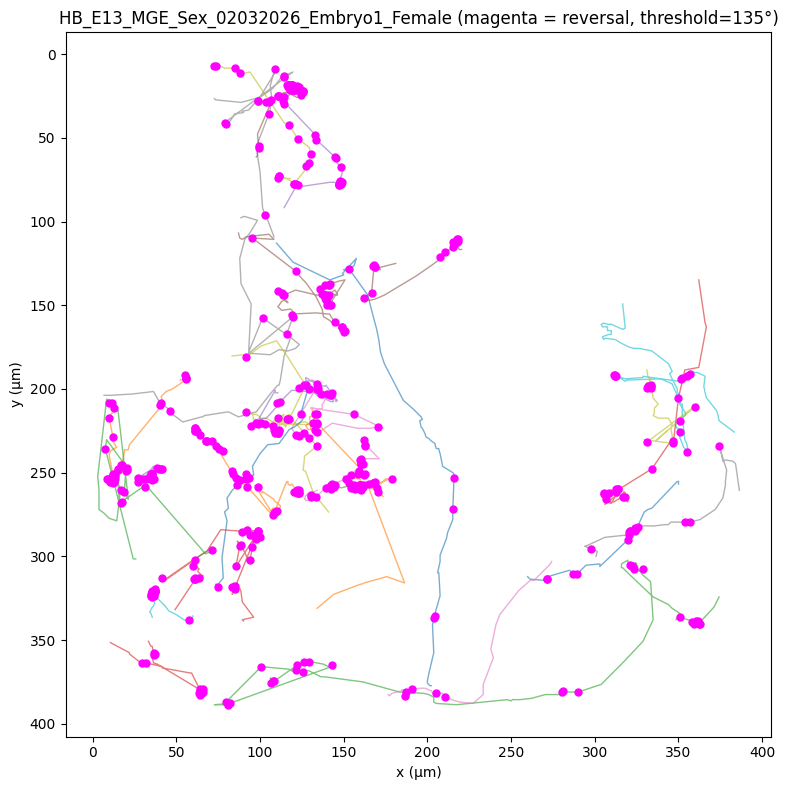

  Tracks meeting duration cutoff: 29, reversal steps: 498

HB_E13_MGE_Sex_02032026_Embryo2_Male
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  6.86it/s]


    frame 1/129: 20 objects


100%|██████████| 4/4 [00:00<00:00,  7.01it/s]


    frame 2/129: 18 objects


...

100%|██████████| 4/4 [00:00<00:00, 10.37it/s]


    frame 128/129: 24 objects


100%|██████████| 4/4 [00:00<00:00, 10.78it/s]


    frame 129/129: 29 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo2_Male_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


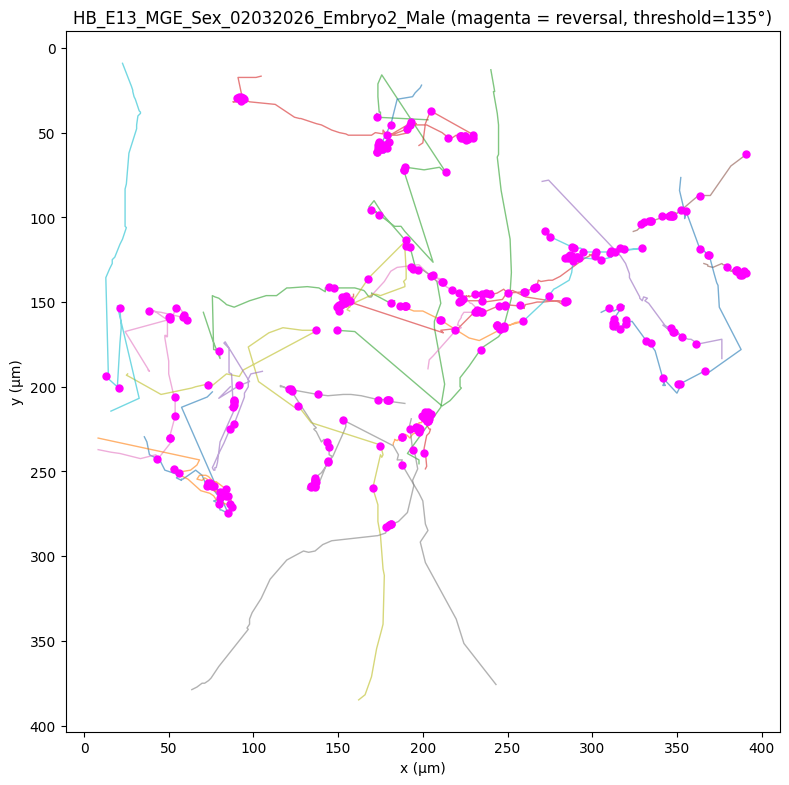

  Tracks meeting duration cutoff: 24, reversal steps: 309

HB_E13_MGE_Sex_02032026_Embryo3_Male
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.29it/s]


    frame 1/129: 29 objects


100%|██████████| 4/4 [00:00<00:00,  7.91it/s]


    frame 2/129: 33 objects


...

100%|██████████| 4/4 [00:00<00:00, 10.37it/s]


    frame 128/129: 37 objects


100%|██████████| 4/4 [00:00<00:00, 10.42it/s]


    frame 129/129: 42 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo3_Male_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


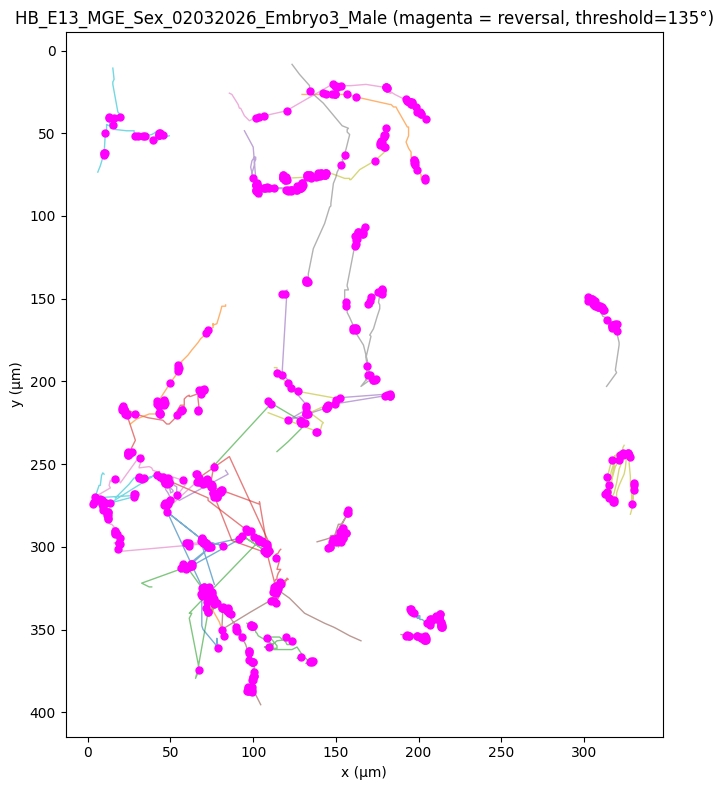

  Tracks meeting duration cutoff: 30, reversal steps: 751

HB_E13_MGE_Sex_02032026_Embryo4_Female
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.45it/s]


    frame 1/129: 17 objects


100%|██████████| 4/4 [00:00<00:00,  7.97it/s]


    frame 2/129: 15 objects


...

100%|██████████| 4/4 [00:00<00:00,  9.59it/s]


    frame 128/129: 23 objects


100%|██████████| 4/4 [00:00<00:00,  8.57it/s]


    frame 129/129: 20 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo4_Female_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


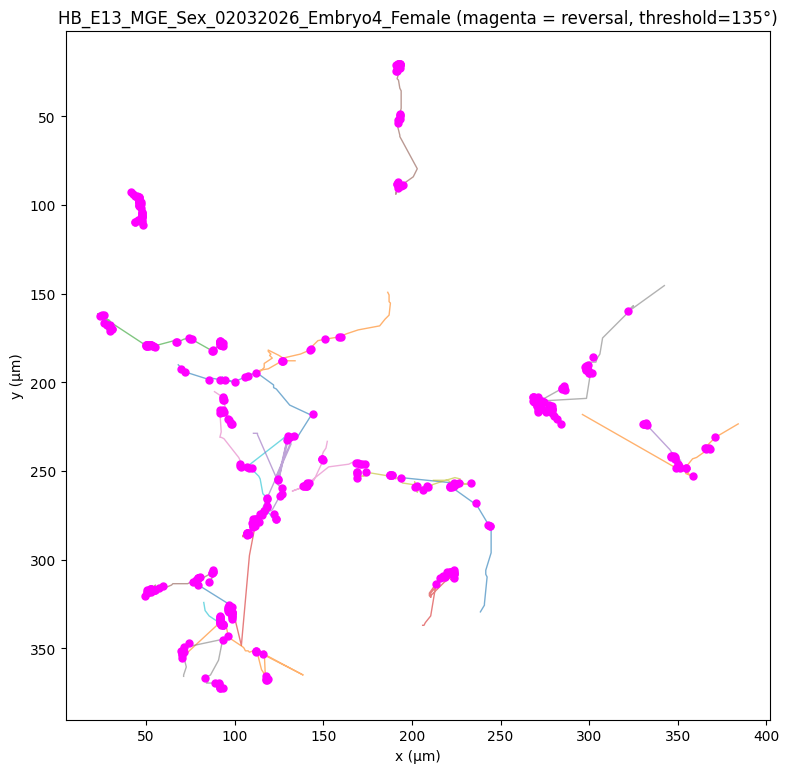

  Tracks meeting duration cutoff: 23, reversal steps: 479

HB_E13_MGE_Sex_02032026_Embryo5_Female
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.42it/s]


    frame 1/129: 39 objects


100%|██████████| 4/4 [00:00<00:00,  8.06it/s]


    frame 2/129: 38 objects


...

100%|██████████| 4/4 [00:00<00:00, 10.35it/s]


    frame 128/129: 77 objects


100%|██████████| 4/4 [00:00<00:00, 10.06it/s]


    frame 129/129: 82 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo5_Female_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


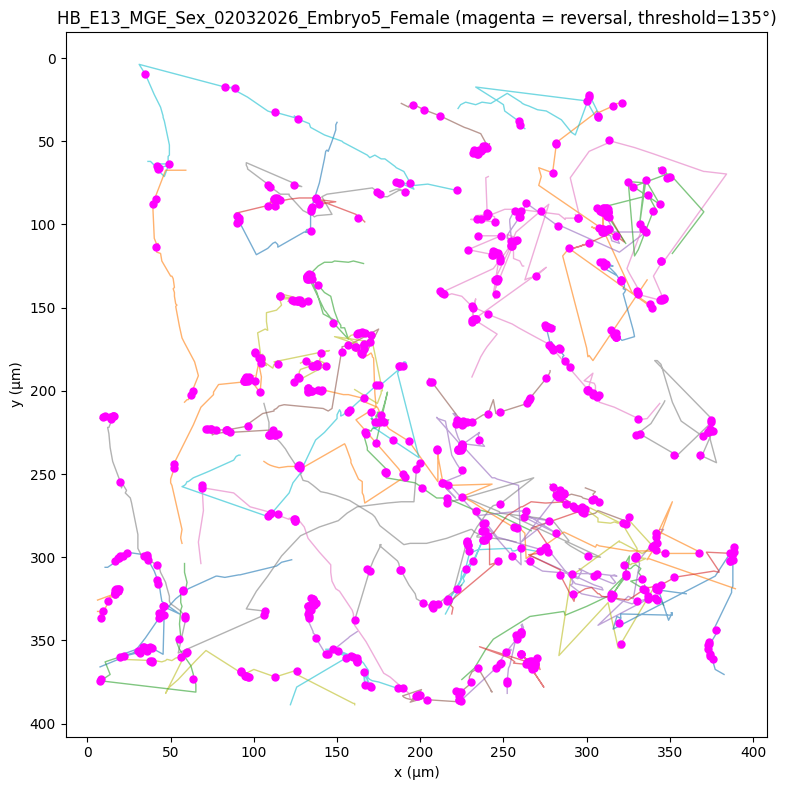

  Tracks meeting duration cutoff: 52, reversal steps: 735

HB_E13_MGE_Sex_02032026_Embryo6_Male
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  5.67it/s]


    frame 1/129: 34 objects


100%|██████████| 4/4 [00:00<00:00,  8.33it/s]


    frame 2/129: 40 objects


...

100%|██████████| 4/4 [00:00<00:00,  5.24it/s]


    frame 128/129: 38 objects


100%|██████████| 4/4 [00:00<00:00,  7.84it/s]


    frame 129/129: 41 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo6_Male_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


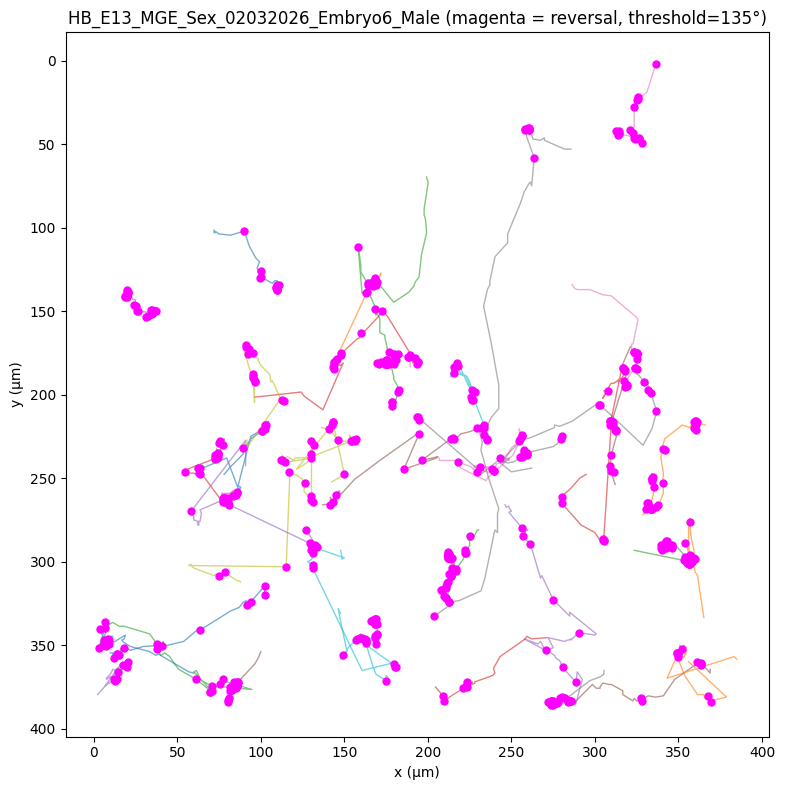

  Tracks meeting duration cutoff: 38, reversal steps: 560

HB_E13_MGE_Sex_02032026_Embryo7_Male
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.15it/s]


    frame 1/129: 6 objects


100%|██████████| 4/4 [00:00<00:00,  7.42it/s]


    frame 2/129: 5 objects


...

100%|██████████| 4/4 [00:00<00:00,  8.63it/s]


    frame 128/129: 11 objects


100%|██████████| 4/4 [00:00<00:00,  9.66it/s]


    frame 129/129: 11 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo7_Male_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


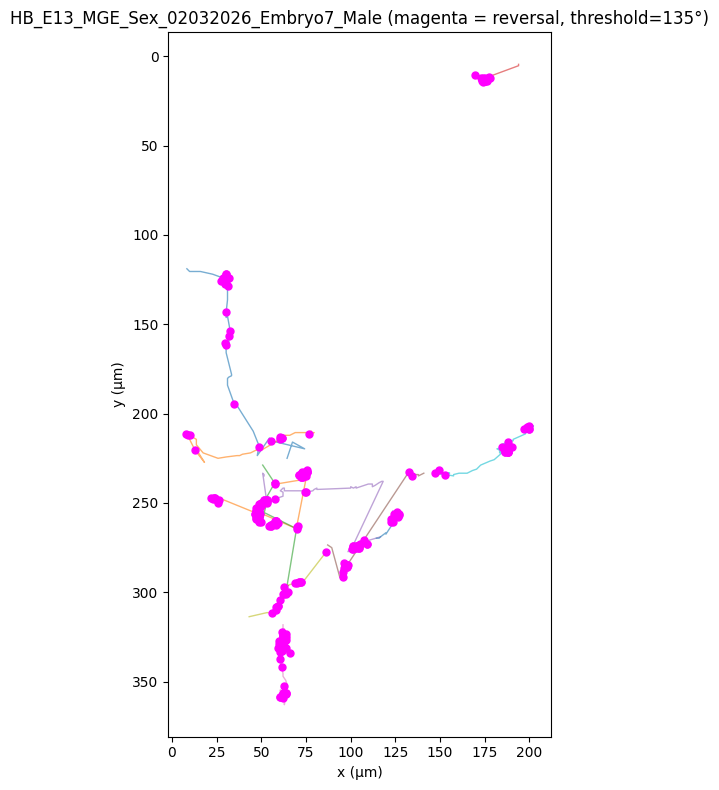

  Tracks meeting duration cutoff: 12, reversal steps: 279

HB_E13_MGE_Sex_02032026_Embryo8_Female
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.32it/s]


    frame 1/129: 13 objects


100%|██████████| 4/4 [00:00<00:00,  8.05it/s]


    frame 2/129: 14 objects


...

100%|██████████| 4/4 [00:00<00:00, 10.48it/s]


    frame 128/129: 23 objects


100%|██████████| 4/4 [00:00<00:00, 10.32it/s]


    frame 129/129: 23 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo8_Female_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


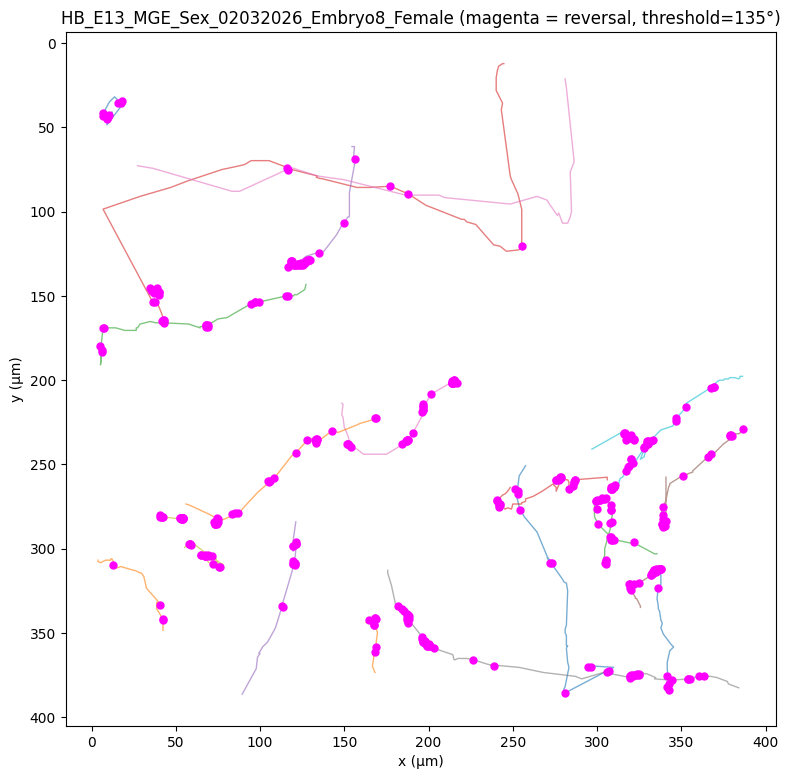

  Tracks meeting duration cutoff: 22, reversal steps: 417

BATCH COMPLETE
Processed: 8 / 8


In [75]:
#Run the batch analysis

all_tracks = []
all_summaries = []
failed_files = []

for input_path in input_paths:
    try:
        tracks_df, track_summary = process_single_movie(
    input_path, model, OUTPUT_DIR,
    MAX_DISPLACEMENT_UM, REVERSAL_ANGLE_THRESHOLD_DEG, n_tiles=N_TILES,
    max_frame_gap=MAX_FRAME_GAP,
    pause_threshold_um=PAUSE_THRESHOLD_UM,
    nucleokinesis_threshold_um=NUCLEOKINESIS_THRESHOLD_UM,
    min_track_duration_hours=MIN_TRACK_DURATION_HOURS,
)
        all_tracks.append(tracks_df)
        all_summaries.append(track_summary)
    except Exception as e:
        print(f"  FAILED: {os.path.basename(input_path)} -> {e}")
        failed_files.append((input_path, str(e)))

print("\n================================")
print("BATCH COMPLETE")
print("================================")
print(f"Processed: {len(all_tracks)} / {len(input_paths)}")
if failed_files:
    print("Failed files:")
    for p, err in failed_files:
        print(" ", os.path.basename(p), "-", err)

In [76]:
#Combine tracks across all movies


combined_tracks_df = pd.concat(all_tracks, ignore_index=True) if all_tracks else pd.DataFrame()
combined_summary_df = pd.concat(all_summaries, ignore_index=True) if all_summaries else pd.DataFrame()

combined_tracks_path = os.path.join(OUTPUT_DIR, "all_movies_tracks.csv")
combined_summary_path = os.path.join(OUTPUT_DIR, "all_movies_track_summary.csv")

combined_tracks_df.to_csv(combined_tracks_path, index=False)
combined_summary_df.to_csv(combined_summary_path, index=False)

print("Combined per-detection table:", combined_tracks_path)
print("Combined per-track summary:  ", combined_summary_path)

if not combined_summary_df.empty:
    print("\nReversals per movie:")
    print(combined_summary_df.groupby("movie")["n_reversals"].sum())

Combined per-detection table: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/all_movies_tracks.csv
Combined per-track summary:   /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/all_movies_track_summary.csv

Reversals per movie:
movie
HB_E13_MGE_Sex_02032026_Embryo1_Female    498.0
HB_E13_MGE_Sex_02032026_Embryo2_Male      309.0
HB_E13_MGE_Sex_02032026_Embryo3_Male      751.0
HB_E13_MGE_Sex_02032026_Embryo4_Female    479.0
HB_E13_MGE_Sex_02032026_Embryo5_Female    735.0
HB_E13_MGE_Sex_02032026_Embryo6_Male      560.0
HB_E13_MGE_Sex_02032026_Embryo7_Male      279.0
HB_E13_MGE_Sex_02032026_Embryo8_Female    417.0
Name: n_reversals, dtype: float64


In [77]:
#Function for defining conditions based on file naming structure

from scipy import stats


def assign_conditions_from_filename(df, tokens, case_sensitive=False, movie_col="movie"):
    """
    Assigns a condition by matching whole underscore-separated segments of
    the filename against the token list - e.g. "..._Female_..." matches the
    "Female" segment exactly, so "Male" won't accidentally match inside it.
    """
    df = df.copy()

    def find_condition(movie_name):
        segments = movie_name.split("_")
        if not case_sensitive:
            segments = [s.lower() for s in segments]
            compare_tokens = [t.lower() for t in tokens]
        else:
            compare_tokens = tokens

        matches = [t for t, t_cmp in zip(tokens, compare_tokens) if t_cmp in segments]
        return matches[0] if len(matches) == 1 else np.nan

    df["condition"] = df[movie_col].apply(find_condition)
    unmatched = df.loc[df["condition"].isna(), movie_col].unique()
    if len(unmatched) > 0:
        print("WARNING: could not assign a single condition to these movies:")
        for m in unmatched:
            print("  ", m)
    return df

In [78]:
#Assign conditions based on above function

CONDITION_TOKENS = ["Male", "Female"] #Change accordingly 
CASE_SENSITIVE = False

combined_summary_df = assign_conditions_from_filename(
    combined_summary_df,
    CONDITION_TOKENS,
    case_sensitive=CASE_SENSITIVE
)

In [79]:
#Metrics for stats and plotting

METRIC_COLUMNS = ['velocity_um_per_hour', 'nucleokinesis_frequency_per_hour', 'mean_nucleokinesis_amplitude', 'reversal_frequency_per_hour', 
'avg_reversal_angle_deg', 'straightness_index', 'pause_percentage']

ALPHA = 0.05

In [80]:
#Visualise per-movie n breakdown so you can see track counts and movie counts side by side.
#This is imporant for stats: currently most people in the lab treat each track/neuron as an n
#It is more appropriate to treat each experiment as an n 

print("Tracks per movie:")
print(combined_summary_df.groupby(["condition", "movie"])["track_id"].count())

print("\nMovies per condition:")
print(combined_summary_df.groupby("condition")["movie"].nunique())

print("\nTracks per condition (track-level n):")
print(combined_summary_df.groupby("condition")["track_id"].count())

Tracks per movie:
condition  movie                                 
Female     HB_E13_MGE_Sex_02032026_Embryo1_Female    29
           HB_E13_MGE_Sex_02032026_Embryo4_Female    23
           HB_E13_MGE_Sex_02032026_Embryo5_Female    52
           HB_E13_MGE_Sex_02032026_Embryo8_Female    22
Male       HB_E13_MGE_Sex_02032026_Embryo2_Male      24
           HB_E13_MGE_Sex_02032026_Embryo3_Male      30
           HB_E13_MGE_Sex_02032026_Embryo6_Male      38
           HB_E13_MGE_Sex_02032026_Embryo7_Male      12
Name: track_id, dtype: int64

Movies per condition:
condition
Female    4
Male      4
Name: movie, dtype: int64

Tracks per condition (track-level n):
condition
Female    126
Male      104
Name: track_id, dtype: int64


In [81]:
#Average tracks across a single movie to create a per embryo/movie mean

def aggregate_by_movie(df, metric_columns, movie_col="movie", group_col="condition"):
    """
    Collapses track-level data to one row per movie by averaging each metric
    across that movie's tracks. This makes the movie (not the track) the
    unit of replication - the statistically appropriate level when tracks
    from the same movie aren't independent of each other.
    """
    agg_dict = {m: "mean" for m in metric_columns}
    movie_df = (
        df.groupby([movie_col, group_col])
        .agg(agg_dict)
        .reset_index()
    )
    n_tracks = df.groupby([movie_col, group_col]).size().reset_index(name="n_tracks")
    movie_df = movie_df.merge(n_tracks, on=[movie_col, group_col])
    return movie_df


movie_level_df = aggregate_by_movie(combined_summary_df, METRIC_COLUMNS)
print(movie_level_df)

                                    movie condition  velocity_um_per_hour  \
0  HB_E13_MGE_Sex_02032026_Embryo1_Female    Female             27.546709   
1    HB_E13_MGE_Sex_02032026_Embryo2_Male      Male             32.597103   
2    HB_E13_MGE_Sex_02032026_Embryo3_Male      Male             18.542010   
3  HB_E13_MGE_Sex_02032026_Embryo4_Female    Female             15.958957   
4  HB_E13_MGE_Sex_02032026_Embryo5_Female    Female             32.105002   
5    HB_E13_MGE_Sex_02032026_Embryo6_Male      Male             24.249301   
6    HB_E13_MGE_Sex_02032026_Embryo7_Male      Male             15.717108   
7  HB_E13_MGE_Sex_02032026_Embryo8_Female    Female             18.761595   

   nucleokinesis_frequency_per_hour  mean_nucleokinesis_amplitude  \
0                          1.385167                     12.564993   
1                          1.673552                     12.604064   
2                          0.747008                     13.864146   
3                          0.5

In [82]:
#Nested model allowing all tracks in each individual movie to be used in comparisons,
# while keeping the statistics correct

#Nested model allowing for use of multiple tracks, while keeping the statistics proper
#Falls back to cluster-robust OLS if the mixed model's variance component is singular/unreliable

import statsmodels.formula.api as smf
import warnings

def run_nested_model(df, metric, movie_col="movie", group_col="condition", alpha=0.05):
    data = df[[metric, group_col, movie_col]].dropna().copy()
    data[group_col] = data[group_col].astype("category")
    n_conditions = data[group_col].nunique()
    n_movies = data[movie_col].nunique()

    if n_conditions < 2 or n_movies < 2:
        return {"metric": metric, "n_conditions": n_conditions, "n_movies": n_movies,
                "n_tracks": len(data), "test": "skipped (insufficient groups/movies)",
                "statistic": np.nan, "p_value": np.nan, "significant": np.nan,
                "converged": np.nan}

    if n_conditions == 2:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            full_result = smf.mixedlm(f"{metric} ~ {group_col}", data, groups=data[movie_col]).fit(
                reml=False, method=["lbfgs", "bfgs", "cg"], maxiter=500
            )
            singular = any("singular" in str(w.message).lower() for w in caught)

        converged = bool(getattr(full_result, "converged", False)) and not singular

        if converged:
            coef_name = [c for c in full_result.params.index if c.startswith(group_col)][0]
            statistic = full_result.tvalues[coef_name]
            p_value = full_result.pvalues[coef_name]
            test_name = "Mixed model (Wald test, movie random intercept)"
        else:
            # Mixed model's variance component is unreliable (singular / boundary) -
            # fall back to cluster-robust OLS, which doesn't need to estimate a
            # variance component via MLE at all.
            ols_result = smf.ols(f"{metric} ~ C({group_col})", data=data).fit(
                cov_type="cluster", cov_kwds={"groups": data[movie_col]}
            )
            coef_name = [c for c in ols_result.params.index if c.startswith(f"C({group_col})")][0]
            statistic = ols_result.tvalues[coef_name]
            p_value = ols_result.pvalues[coef_name]
            test_name = "OLS with cluster-robust SE (mixed model fallback - singular variance component)"

    else:
        # >2 conditions: same fallback logic, via likelihood ratio test / F-test
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            full_result = smf.mixedlm(f"{metric} ~ {group_col}", data, groups=data[movie_col]).fit(
                reml=False, method=["lbfgs", "bfgs", "cg"], maxiter=500
            )
            reduced_result = smf.mixedlm(f"{metric} ~ 1", data, groups=data[movie_col]).fit(
                reml=False, method=["lbfgs", "bfgs", "cg"], maxiter=500
            )
            singular = any("singular" in str(w.message).lower() for w in caught)

        converged = (bool(getattr(full_result, "converged", False))
                     and bool(getattr(reduced_result, "converged", False)) and not singular)

        if converged:
            lr_stat = 2 * (full_result.llf - reduced_result.llf)
            p_value = stats.chi2.sf(lr_stat, n_conditions - 1)
            statistic = lr_stat
            test_name = "Mixed model (likelihood ratio test, movie random intercept)"
        else:
            ols_result = smf.ols(f"{metric} ~ C({group_col})", data=data).fit(
                cov_type="cluster", cov_kwds={"groups": data[movie_col]}
            )
            statistic, p_value = ols_result.fvalue, ols_result.f_pvalue
            test_name = "OLS with cluster-robust SE (mixed model fallback - singular variance component)"

    return {
        "metric": metric, "n_conditions": n_conditions, "n_movies": n_movies,
        "n_tracks": len(data), "test": test_name,
        "statistic": statistic, "p_value": p_value, "significant": p_value < alpha,
        "converged": converged,
    }


def run_nested_comparisons(df, metric_columns, movie_col="movie", group_col="condition", alpha= ALPHA):
    return pd.DataFrame([run_nested_model(df, m, movie_col, group_col, alpha) for m in metric_columns])

In [83]:
#Residual normality

def check_residual_normality(df, metric, movie_col="movie", group_col="condition"):
    data = df[[metric, group_col, movie_col]].dropna().copy()
    if data[group_col].nunique() < 2 or data[movie_col].nunique() < 2 or len(data) < 3:
        return {"metric": metric, "W": np.nan, "p_value": np.nan, "residuals_normal": np.nan,
                "note": "insufficient data"}

    try:
        model = smf.mixedlm(f"{metric} ~ {group_col}", data, groups=data[movie_col]).fit(
            reml=False, method=["lbfgs", "bfgs", "cg"], maxiter=500
        )
        resid = model.resid  # this is what raises on a singular covariance structure
    except (ValueError, np.linalg.LinAlgError):
        return {"metric": metric, "W": np.nan, "p_value": np.nan, "residuals_normal": np.nan,
                "note": "singular covariance - residuals unavailable (see run_nested_comparisons fallback)"}

    W, p = stats.shapiro(resid)
    return {"metric": metric, "W": W, "p_value": p, "residuals_normal": p > ALPHA, "note": ""}


def check_all_residual_normality(df, metric_columns):
    return pd.DataFrame([check_residual_normality(df, m) for m in metric_columns])
    return pd.DataFrame([check_residual_normality(df, m) for m in metric_columns])

In [84]:
#Test data for normality 

def test_normality(df, metric_columns, group_col="condition", alpha=0.05):
    """Shapiro-Wilk normality test per (condition, metric). Needs n>=3 per group."""
    rows = []
    for metric in metric_columns:
        for condition, group in df.groupby(group_col):
            values = group[metric].dropna()
            n = len(values)
            if n < 3:
                rows.append({"metric": metric, "condition": condition, "n": n,
                             "W": np.nan, "p_value": np.nan, "is_normal": np.nan})
                continue
            W, p = stats.shapiro(values)
            rows.append({"metric": metric, "condition": condition, "n": n,
                         "W": W, "p_value": p, "is_normal": p > alpha})
    return pd.DataFrame(rows)


def summarize_by_condition(df, metric_columns, group_col="condition"):
    rows = []
    for metric in metric_columns:
        for condition, group in df.groupby(group_col):
            values = group[metric].dropna()
            rows.append({
                "metric": metric,
                "condition": condition,
                "n": len(values),
                "mean": values.mean(),
                "sem": values.sem() if len(values) > 1 else np.nan,
                "std": values.std(),
                "median": values.median(),
                "iqr": (values.quantile(0.75) - values.quantile(0.25)) if len(values) > 0 else np.nan,
            })
    return pd.DataFrame(rows)

In [85]:
#automatic determination of appropriate statistical tests

def run_group_comparisons(df, metric_columns, normality_df, group_col="condition", alpha=0.05):
    """
    2 conditions: Welch's t-test if both groups pass Shapiro-Wilk, else Mann-Whitney U.
    >2 conditions: one-way ANOVA if all groups pass Shapiro-Wilk, else Kruskal-Wallis.
    A group with an unknown/failed normality result (n<3) is treated as non-normal,
    so the safer non-parametric test is used when in doubt.
    """
    conditions = sorted(df[group_col].dropna().unique())
    n_conditions = len(conditions)

    if n_conditions < 2:
        print("Only one condition present - nothing to compare.")
        return pd.DataFrame()

    results = []
    for metric in metric_columns:
        groups = [df.loc[df[group_col] == c, metric].dropna() for c in conditions]

        if any(len(g) < 2 for g in groups):
            results.append({"metric": metric, "n_conditions": n_conditions,
                             "conditions": ", ".join(conditions),
                             "test": "skipped (insufficient data)",
                             "statistic": np.nan, "p_value": np.nan, "significant": np.nan})
            continue

        all_normal = normality_df.loc[normality_df["metric"] == metric, "is_normal"].fillna(False).all()

        if n_conditions == 2:
            if all_normal:
                stat, p = stats.ttest_ind(groups[0], groups[1], equal_var=False)
                test_name = "Welch's t-test"
            else:
                stat, p = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
                test_name = "Mann-Whitney U"
        else:
            if all_normal:
                stat, p = stats.f_oneway(*groups)
                test_name = "One-way ANOVA"
            else:
                stat, p = stats.kruskal(*groups)
                test_name = "Kruskal-Wallis"

        results.append({"metric": metric, "n_conditions": n_conditions,
                         "conditions": ", ".join(conditions), "test": test_name,
                         "statistic": stat, "p_value": p, "significant": p < alpha})

    return pd.DataFrame(results)

In [86]:
def plot_condition_comparisons(df, metric_columns, comparison_df,
                               group_col="condition", save_path=None):

    conditions = ["Female", "Male"]
    conditions = [c for c in conditions if c in df[group_col].dropna().unique()]

    n_cols = 3
    n_rows = int(np.ceil(len(metric_columns) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4.5 * n_rows)
    )

    axes = np.atleast_1d(axes).flatten()

    # Pastel colours
    condition_colors = {
        "Female": "#9AD9D0",   # You can change these as desired
        "Male": "#E6A1C5"      # You can change these as desired
    }

    rng = np.random.default_rng(0)

    for ax, metric in zip(axes, metric_columns):

        data = [
            df.loc[df[group_col] == c, metric].dropna().values
            for c in conditions
        ]

        # Violin plot
        vp = ax.violinplot(
            data,
            positions=np.arange(1, len(conditions) + 1),
            showmeans=False,
            showmedians=True,
            showextrema=False
        )

        # Colour each violin
        for body, condition in zip(vp["bodies"], conditions):
            body.set_facecolor(condition_colors[condition])
            body.set_edgecolor("black")
            body.set_alpha(0.65)

        # Median lines
        if "cmedians" in vp:
            vp["cmedians"].set_color("black")
            vp["cmedians"].set_linewidth(1.5)

        # Individual data points
        for i, (condition, values) in enumerate(
            zip(conditions, data),
            start=1
        ):
            jitter = rng.normal(
                loc=i,
                scale=0.04,
                size=len(values)
            )

            ax.scatter(
                jitter,
                values,
                alpha=0.45,
                s=15,
                color=condition_colors[condition],
                edgecolor="white",
                linewidth=0.4,
                zorder=3
            )

        # Statistical result
        p_row = comparison_df.loc[
            comparison_df["metric"] == metric
        ]

        if len(p_row) > 0 and pd.notna(
            p_row["p_value"].values[0]
        ):
            ax.set_title(
                f"{metric}\n"
                f"{p_row['test'].values[0]}, "
                f"p={p_row['p_value'].values[0]:.4g}"
            )
        else:
            ax.set_title(metric)

        ax.set_xticks(np.arange(1, len(conditions) + 1))
        ax.set_xticklabels(conditions)

        ax.set_ylabel(metric)

        # Clean appearance
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.yaxis.grid(
            True,
            linestyle="--",
            alpha=0.25
        )
        ax.set_axisbelow(True)

    # Hide unused axes
    for ax in axes[len(metric_columns):]:
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

model.py (589): Random effects covariance is singular
mixed_linear_model.py (2429): The random effects covariance matrix is singular.
3722988806.py (10): The MLE may be on the boundary of the parameter space.
3722988806.py (10): The random effects covariance matrix is singular.
3722988806.py (10): The Hessian matrix at the estimated parameter values is not positive definite.
model.py (589): Random effects covariance is singular
mixed_linear_model.py (2429): The random effects covariance matrix is singular.
3722988806.py (10): The MLE may be on the boundary of the parameter space.
3722988806.py (10): The random effects covariance matrix is singular.
3722988806.py (10): The Hessian matrix at the estimated parameter values is not positive definite.
model.py (589): Random effects covariance is singular
mixed_linear_model.py (2429): The random effects covariance matrix is singular.
3722988806.py (10): The MLE may be on the boundary of the parameter space.
3722988806.py (10): The random effe

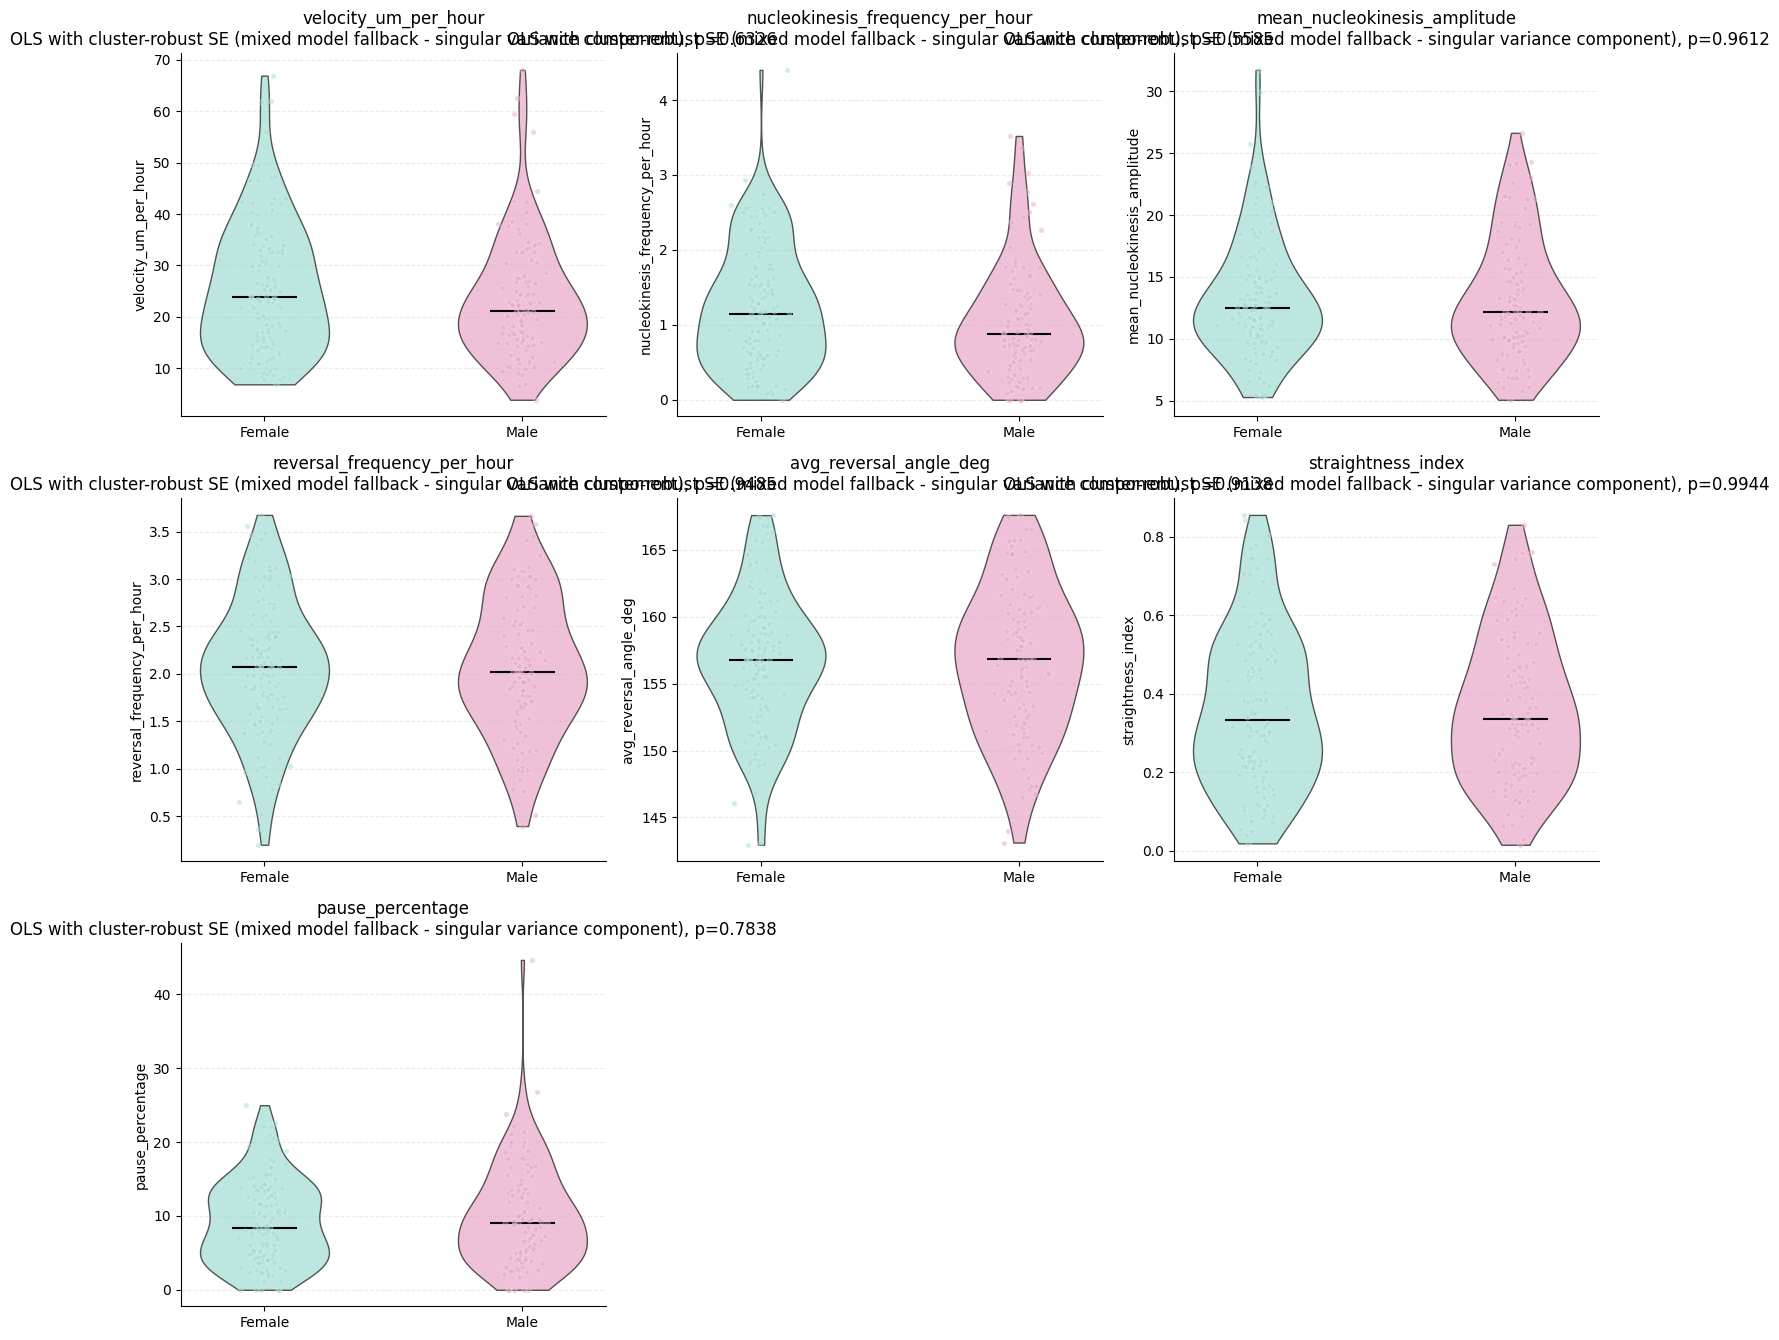

Nested model comparisons: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/stats/condition_comparison_tests_nested_model.csv
                             metric  n_movies  n_tracks  \
0              velocity_um_per_hour         8       230   
1  nucleokinesis_frequency_per_hour         8       230   
2      mean_nucleokinesis_amplitude         8       225   
3       reversal_frequency_per_hour         8       230   
4            avg_reversal_angle_deg         8       230   
5                straightness_index         8       230   
6                  pause_percentage         8       230   

                                                test   p_value  significant  
0  OLS with cluster-robust SE (mixed model fallba...  0.632630        False  
1  OLS with cluster-robust SE (mixed model fallba...  0.558523        False  
2  OLS with cluster-robust SE (mixed model fallba...  0.961180        False  
3  OLS with cluster-robust SE (mixed model fallba...  0.948549        False  
4  OLS 

In [87]:
#Run nested model analysis.
#Still uses all tracks from each movie, but correctly treats each movie/embryo as a seperate n

nested_comparison_df = run_nested_comparisons(combined_summary_df, METRIC_COLUMNS, alpha=ALPHA)
nested_residual_normality_df = check_all_residual_normality(combined_summary_df, METRIC_COLUMNS)

# Movie-level descriptive stats: one value per movie per metric (averaged
# across that movie's tracks), then mean/SD of those across movies within
# each condition - the descriptive companion to the nested model's p-values,
# since it uses the same "movie as the unit" logic rather than pooling tracks.

def aggregate_by_movie(df, metric_columns, movie_col="movie", group_col="condition"):
    agg_dict = {m: "mean" for m in metric_columns}
    return df.groupby([movie_col, group_col]).agg(agg_dict).reset_index()

movie_level_df = aggregate_by_movie(combined_summary_df, METRIC_COLUMNS)
movie_descriptive_df = summarize_by_condition(movie_level_df, METRIC_COLUMNS)

nested_comparison_path = os.path.join(STATS_OUTPUT_DIR, "condition_comparison_tests_nested_model.csv")
nested_residual_path = os.path.join(STATS_OUTPUT_DIR, "condition_residual_normality_nested_model.csv")
movie_descriptive_path = os.path.join(STATS_OUTPUT_DIR, "condition_summary_stats_nested_model.csv")
nested_plot_path = os.path.join(STATS_OUTPUT_DIR, "condition_comparison_plots_nested_model.png")

nested_comparison_df.to_csv(nested_comparison_path, index=False)
nested_residual_normality_df.to_csv(nested_residual_path, index=False)
movie_descriptive_df.to_csv(movie_descriptive_path, index=False)
plot_condition_comparisons(combined_summary_df, METRIC_COLUMNS, nested_comparison_df, save_path=nested_plot_path)

print("Nested model comparisons:", nested_comparison_path)
print(nested_comparison_df[["metric", "n_movies", "n_tracks", "test", "p_value", "significant"]])
print("\nMovie-level descriptive stats:", movie_descriptive_path)
print(movie_descriptive_df[["metric", "condition", "n", "mean", "std"]])

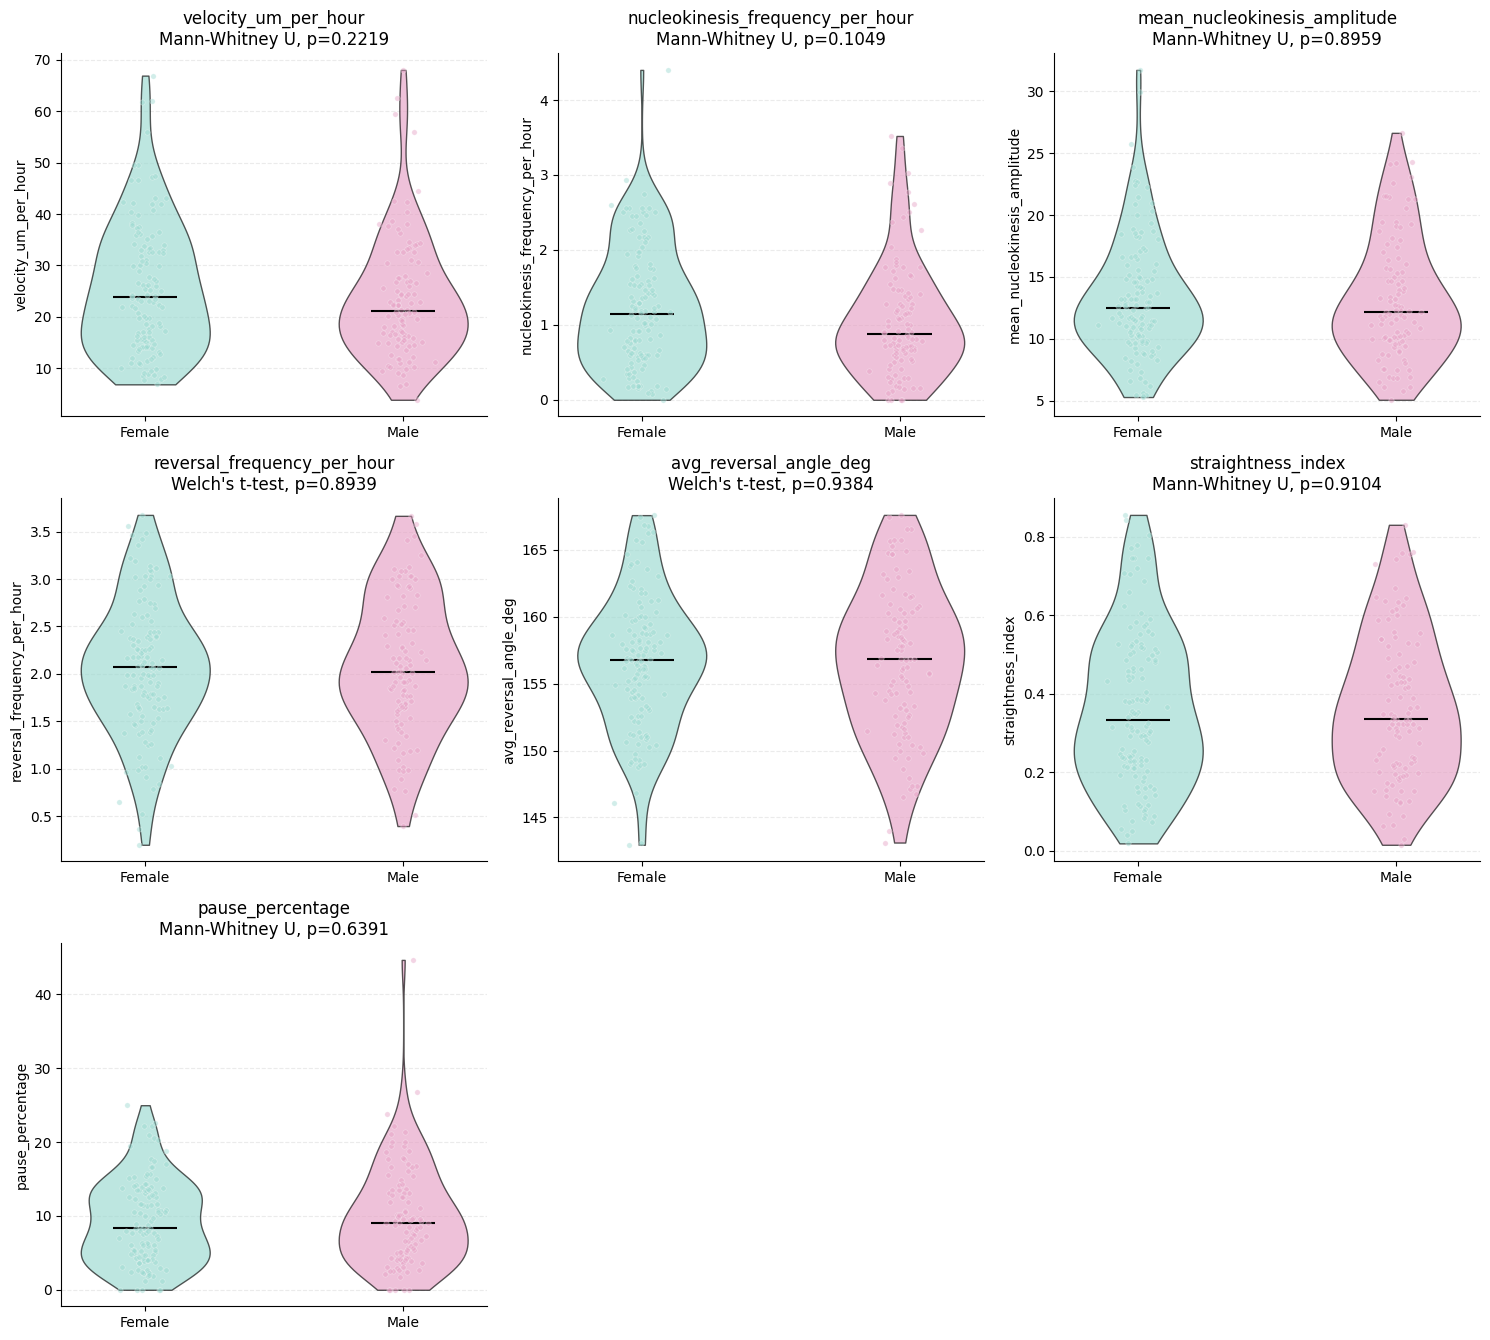


=== TRACK_LEVEL (n reflects tracks) ===
                             metric            test   p_value  significant
0              velocity_um_per_hour  Mann-Whitney U  0.221893        False
1  nucleokinesis_frequency_per_hour  Mann-Whitney U  0.104863        False
2      mean_nucleokinesis_amplitude  Mann-Whitney U  0.895875        False
3       reversal_frequency_per_hour  Welch's t-test  0.893906        False
4            avg_reversal_angle_deg  Welch's t-test  0.938372        False
5                straightness_index  Mann-Whitney U  0.910431        False
6                  pause_percentage  Mann-Whitney U  0.639129        False


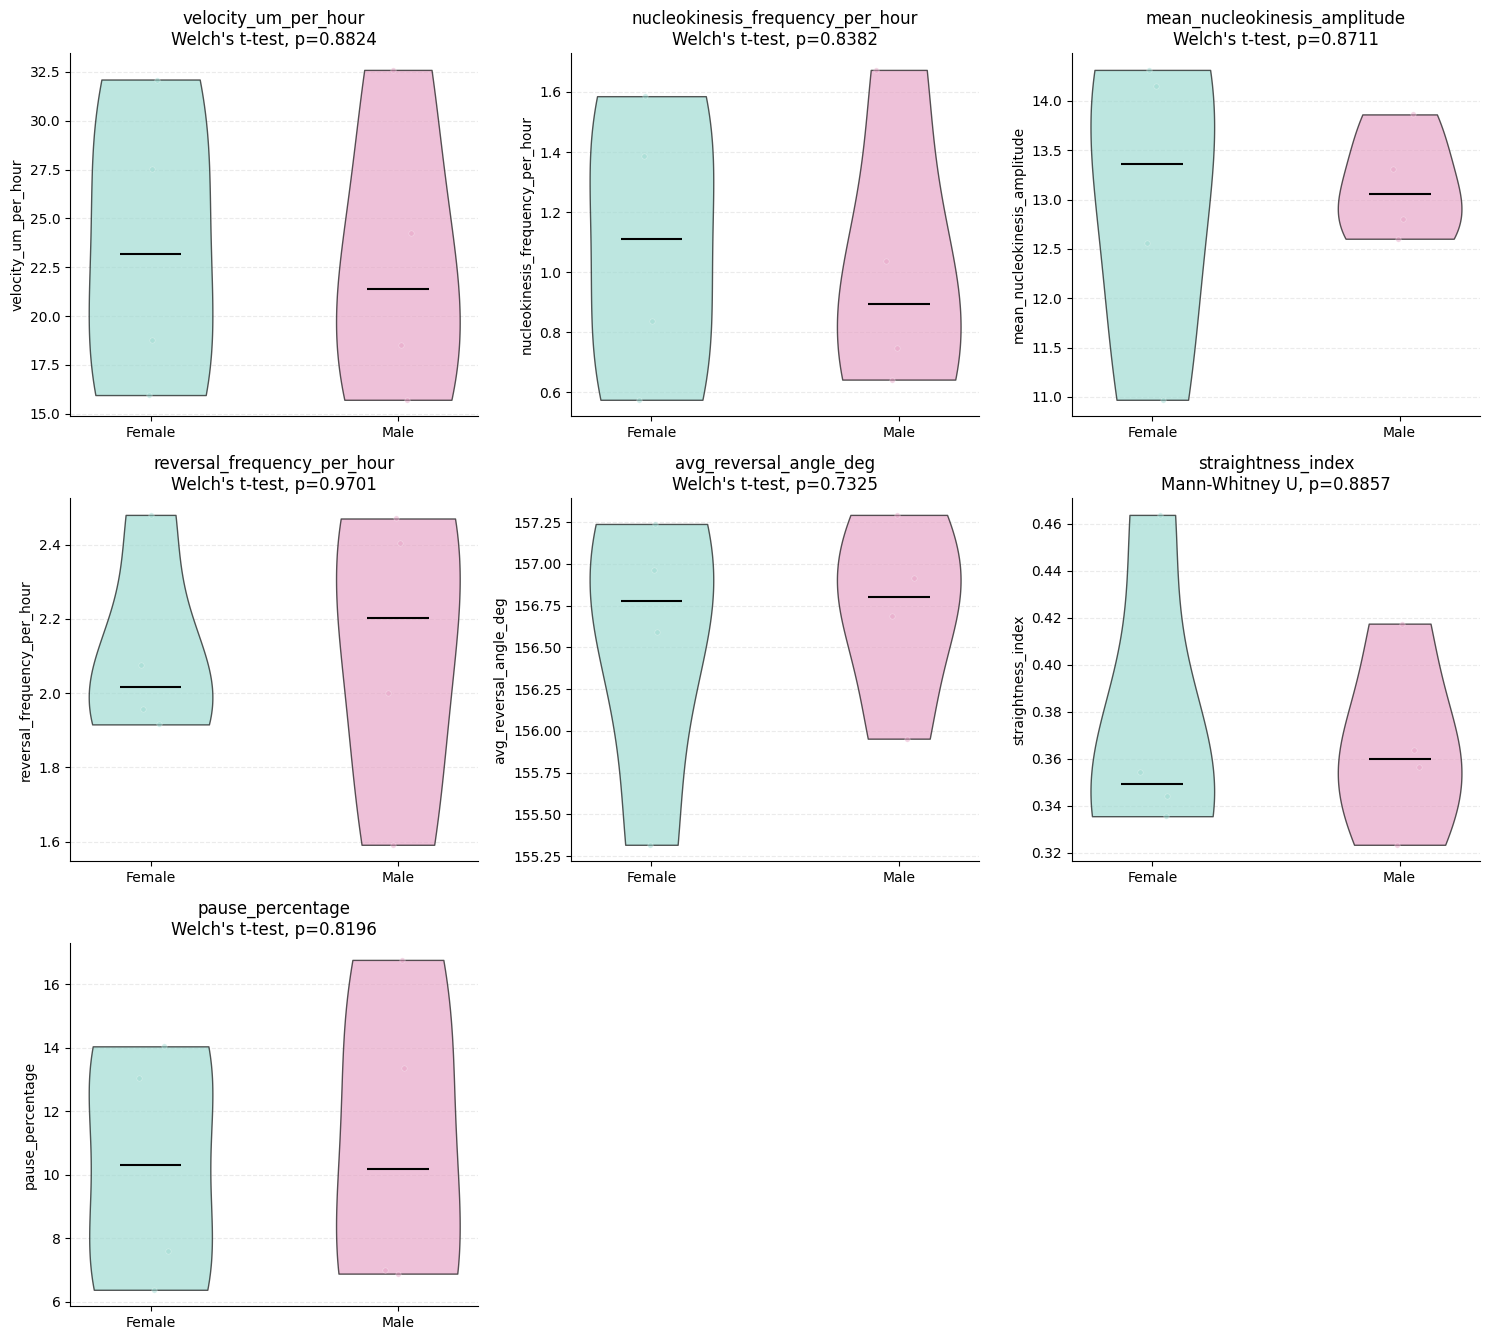


=== MOVIE_LEVEL (n reflects movies) ===
                             metric            test   p_value  significant
0              velocity_um_per_hour  Welch's t-test  0.882419        False
1  nucleokinesis_frequency_per_hour  Welch's t-test  0.838151        False
2      mean_nucleokinesis_amplitude  Welch's t-test  0.871137        False
3       reversal_frequency_per_hour  Welch's t-test  0.970137        False
4            avg_reversal_angle_deg  Welch's t-test  0.732503        False
5                straightness_index  Mann-Whitney U  0.885714        False
6                  pause_percentage  Welch's t-test  0.819597        False


In [88]:
#Run analysis treating each cell tracked as an individual n and also averaging tracks across movies/embryos

def run_full_analysis(df, metric_columns, label, output_dir, alpha=0.05):
    """Runs normality + comparison tests + plot, saving everything with a
    filename suffix identifying which level ('track_level' or 'movie_level')
    the analysis was run at."""
    normality_df = test_normality(df, metric_columns, alpha=alpha)
    descriptive_df = summarize_by_condition(df, metric_columns)
    comparison_df = run_group_comparisons(df, metric_columns, normality_df, alpha=alpha)

    normality_path = os.path.join(output_dir, f"condition_normality_tests_{label}.csv")
    descriptive_path = os.path.join(output_dir, f"condition_summary_stats_{label}.csv")
    comparison_path = os.path.join(output_dir, f"condition_comparison_tests_{label}.csv")
    plot_path = os.path.join(output_dir, f"condition_comparison_plots_{label}.png")

    normality_df.to_csv(normality_path, index=False)
    descriptive_df.to_csv(descriptive_path, index=False)
    comparison_df.to_csv(comparison_path, index=False)
    plot_condition_comparisons(df, metric_columns, comparison_df, save_path=plot_path)

    print(f"\n=== {label.upper()} (n reflects {'tracks' if label=='track_level' else 'movies'}) ===")
    print(comparison_df[["metric", "test", "p_value", "significant"]])

    return normality_df, descriptive_df, comparison_df


track_normality, track_descriptive, track_comparison = run_full_analysis(
    combined_summary_df, METRIC_COLUMNS, "track_level", STATS_OUTPUT_DIR, alpha=ALPHA
)

movie_normality, movie_descriptive, movie_comparison = run_full_analysis(
    movie_level_df, METRIC_COLUMNS, "movie_level", STATS_OUTPUT_DIR, alpha=ALPHA
)